# Query session database

When you interact with protein-detective a session database is created to store the results of your queries. This notebook shows how to query that database.

This notebooks expects that you have run the [workflow.ipynb](workflow.ipynb) notebook first to create and fill the session database.

In [1]:
from pathlib import Path

from protein_detective.db import connect

Configure [%sql magic](https://jupysql.ploomber.io/en/latest/quick-start.html#querying) to use the session database.

In [2]:
session_dir = Path("session1")
# connect() is a context manager, to use connection over multiple cells, we cal its enter method directly.
conn = connect(session_dir, read_only=True).__enter__()

%load_ext sql
%sql conn
# %sql does not retain variable set in initialize_db(), so we use Python API for queries that need it.

Loading configurations from /home/verhoes/git/protein-detective/protein-detective/pyproject.toml.

Settings changed:

Config,value
displaylimit,100


In [3]:
# Paths in the database are relative to the session directory.
# To make full paths, you need to prepend the session directory.
# The session directory is set as a variable in the database.

conn.execute("SELECT getvariable('session_dir')").fetchone()

('session1',)

## Uniprot search results

In [4]:
%sql SELECT * FROM proteins

Running query in 'DuckDBPyConnection'

uniprot_acc,uniprot_id,sequence_length,reviewed,protein_name,taxon_id,taxon_name
A8K0S8,ME3L2_HUMAN,358,True,Putative homeobox protein Meis3-like 2,9606,Homo sapiens
O00358,FOXE1_HUMAN,373,True,Forkhead box protein E1,9606,Homo sapiens
A0A1B0GVZ6,MB3LB_HUMAN,204,True,Methyl-CpG-binding domain protein 3-like 2B,9606,Homo sapiens
O00287,RFXAP_HUMAN,272,True,Regulatory factor X-associated protein,9606,Homo sapiens
O00479,HMGN4_HUMAN,90,True,High mobility group nucleosome-binding domain-containing protein 4,9606,Homo sapiens
O00321,ETV2_HUMAN,342,True,ETS translocation variant 2,9606,Homo sapiens
O14503,BHE40_HUMAN,412,True,Class E basic helix-loop-helix protein 40,9606,Homo sapiens
B2RPK0,HGB1A_HUMAN,211,True,High mobility group protein B1-like 1,9606,Homo sapiens
A6NE82,MB3L3_HUMAN,208,True,Methyl-CpG-binding domain protein 3-like 3,9606,Homo sapiens
O00571,DDX3X_HUMAN,662,True,ATP-dependent RNA helicase DDX3X,9606,Homo sapiens


In [5]:
%sql SELECT * FROM pdbs

Running query in 'DuckDBPyConnection'

pdb_id,method,resolution,mmcif_file
1H3O,X-Ray_Crystallography,2.299999952316284,downloads/pdbe/1h3o.cif.gz
2P6V,X-Ray_Crystallography,2.0,downloads/pdbe/2p6v.cif.gz
6LTH,Electron_Microscopy,3.0,downloads/pdbe/6lth.cif.gz
6LTJ,Electron_Microscopy,3.700000047683716,downloads/pdbe/6ltj.cif.gz
1RYU,NMR_Spectroscopy,None,downloads/pdbe/1ryu.cif.gz
1WH6,NMR_Spectroscopy,None,downloads/pdbe/1wh6.cif.gz
1WH8,NMR_Spectroscopy,None,downloads/pdbe/1wh8.cif.gz
1X2L,NMR_Spectroscopy,None,downloads/pdbe/1x2l.cif.gz
3TX7,X-Ray_Crystallography,2.759999990463257,downloads/pdbe/3tx7.cif.gz
4DOS,X-Ray_Crystallography,2.0,downloads/pdbe/4dos.cif.gz


In [6]:
%sql SELECT * FROM proteins_pdbs

Running query in 'DuckDBPyConnection'

uniprot_acc,pdb_id,uniprot_chains,chain
O00268,1H3O,A/C=872-945,A
O00268,2P6V,A=575-688,A
O14497,6LTH,L=1-2285,L
O14497,6LTJ,L=991-2285,L
O14497,1RYU,A=1000-1119,A
O14529,1WH6,A=887-974,A
O14529,1WH8,A=1028-1125,A
O14529,1X2L,A=544-631,A
O00482,3TX7,B=191-541,B
O00482,4DOS,A=299-538,A


In [7]:
%sql SELECT * FROM alphafolds LIMIT 1

Running query in 'DuckDBPyConnection'

uniprot_acc,summary,bcif_file,cif_file,pdb_file,pae_doc_file,am_annotations_file,am_annotations_hg19_file,am_annotations_hg38_file,msa_file,plddt_doc_file
A0A087WUV0,"{""allVersions"":[1,2,3,4,5,6],""bcifUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v6.bcif"",""cifUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v6.cif"",""entityType"":""protein"",""fractionPlddtConfident"":0.251,""fractionPlddtLow"":0.088,""fractionPlddtVeryHigh"":0.289,""fractionPlddtVeryLow"":0.372,""globalMetricValue"":66.62,""isUniProt"":true,""latestVersion"":6,""modelCreatedDate"":""2025-08-01T00:00:00Z"",""modelEntityId"":""AF-A0A087WUV0-F1"",""paeDocUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-predicted_aligned_error_v6.json"",""pdbUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v6.pdb"",""providerId"":""GDM"",""sequence"":""MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEALTQWRQLNSPQGDVPEKPRNLVLLGLPISTPDVISQLEHEEELEREVSKAASQKHWETIPESKELTPEKDISEEESAPGVLIVRFSKESSSECEDSLESQQENHEKHLIQEAVTEKSSRERSYQSDEFRRNCTQRSLLVQQQGERLHHCDSFKNNLKQNSDIIRHERICAGKKPWKCNECEKAFSYYSAFVLHQRIHTGEKPYECNECGKAFSQSIHLTLHQRIHTGEKPYECHECGKAFSHRSALIRHHIIHTGEKPYECNECGKAFNQSSYLTQHQRIHTGEKPYECNECGKAFSQSTFLTQHQVIHTGEKPYKCNECGKAFSDRSGLIQHQRTHTGERPYECNECGKAFGYCSALTQHQRTHTGEKPYKCNDCAKAFSDRSALIRHQRTHTGEKPYKCKDCGKAFSQSSSLTKHQKTHTGEKPYKCKECGKAFSQSSSLSQHQKTHAGVKTKKYVQALSEHLTFGQHKRIHTG"",""sequenceChecksum"":""5DE83E4BE25B68BD"",""sequenceEnd"":522,""sequenceStart"":1,""sequenceVersionDate"":""2014-10-29T00:00:00Z"",""toolUsed"":""AlphaFold Monomer v2.0 pipeline"",""alternativeNames"":null,""amAnnotationsHg19Url"":null,""amAnnotationsHg38Url"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-hg38.csv"",""amAnnotationsUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-aa-substitutions.csv"",""catalyticActivities"":null,""complexName"":null,""functions"":null,""gene"":""ZNF892"",""geneSynonyms"":null,""ipSAE"":null,""ipTM"":null,""isUniProtReferenceProteome"":true,""isUniProtReviewed"":true,""keywords"":null,""msaUrl"":""https://alphafold.ebi.ac.uk/files/msa/AF-A0A087WUV0-F1-msa_v6.a3m"",""organismCommonNames"":null,""organismScientificName"":""Homo sapiens"",""organismSynonyms"":null,""plddtDocUrl"":""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-confidence_v6.json"",""proteinFullNames"":null,""proteinShortNames"":null,""stoichiometry"":null,""taxId"":9606,""taxonomyLineage"":null,""uniprotAccession"":""A0A087WUV0"",""uniprotDescription"":""Zinc finger protein 892"",""uniprotId"":""ZN892_HUMAN""}",None,downloads/alphafold/AF-A0A087WUV0-F1-model_v6.cif.gz,None,None,None,None,None,None,None


In [8]:
%sql SELECT count(*) FROM alphafolds

Running query in 'DuckDBPyConnection'

count_star()
100


In [9]:
# Fetch fields from inside summary
%sql SELECT uniprot_acc, summary.taxId, summary.gene, summary.organismScientificName FROM alphafolds

Running query in 'DuckDBPyConnection'

uniprot_acc,taxId,gene,organismScientificName
A0A087WUV0,9606,"""ZNF892""","""Homo sapiens"""
A0A0C5B5G6,9606,"""MT-RNR1""","""Homo sapiens"""
A0A0U1RQI7,9606,"""KLF18""","""Homo sapiens"""
A0A1B0GTS1,9606,"""HSFX4""","""Homo sapiens"""
A0A1B0GVZ6,9606,"""MBD3L2B""","""Homo sapiens"""
A0A1B0GWH4,9606,"""HSFX3""","""Homo sapiens"""
A0A1W2PPF3,9606,"""DUXB""","""Homo sapiens"""
A0A1W2PPK0,9606,"""CPHXL2""","""Homo sapiens"""
A0A1W2PPM1,9606,"""CPHXL""","""Homo sapiens"""
A0A1W2PQ73,9606,"""ERFL""","""Homo sapiens"""


Sequence length of Uniprot protein and alphafold entry

In [11]:
%%sql 
SELECT uniprot_acc, 
proteins.sequence_length,
summary.sequenceStart, summary.sequenceEnd
FROM proteins 
JOIN alphafolds USING (uniprot_acc)
LIMIT 10

Running query in 'DuckDBPyConnection'

uniprot_acc,sequence_length,sequenceStart,sequenceEnd
A0A087WUV0,522,1,522
A0A0C5B5G6,16,1,16
A0A0U1RQI7,1052,1,1052
A0A1B0GTS1,333,1,333
A0A1B0GVZ6,204,1,204
A0A1B0GWH4,333,1,333
A0A1W2PPF3,345,1,345
A0A1W2PPK0,400,1,400
A0A1W2PPM1,405,1,405
A0A1W2PQ73,354,1,354


## Density filtered models

In [10]:
%%sql
SELECT 
f.confidence, f.min_threshold, f.max_threshold,
density_filtered_alphafolds.*, 
alphafolds.summary.uniprotStart, 
alphafolds.summary.uniprotEnd, 
length(alphafolds.summary.uniprotSequence) AS uniprot_length
FROM density_filtered_alphafolds
JOIN density_filters  AS f USING (density_filter_id) 
JOIN alphafolds USING (uniprot_acc)
LIMIT 100;

Running query in 'DuckDBPyConnection'

confidence,min_threshold,max_threshold,density_filter_id,uniprot_acc,nr_residues_above_confidence,keep,pdb_file,uniprotStart,uniprotEnd,uniprot_length
70.0,100,500,1,A0A087WUV0,283,True,density_filtered/AF-A0A087WUV0-F1-model_v4.pdb,1,522,524
70.0,100,500,1,A0A0C5B5G6,10,False,None,1,16,18
70.0,100,500,1,A0A0U1RQI7,192,True,density_filtered/AF-A0A0U1RQI7-F1-model_v4.pdb,1,1052,1054
70.0,100,500,1,A0A1B0GTS1,116,True,density_filtered/AF-A0A1B0GTS1-F1-model_v4.pdb,1,333,335
70.0,100,500,1,A0A1B0GVZ6,54,False,None,1,204,206
70.0,100,500,1,A0A1B0GWH4,117,True,density_filtered/AF-A0A1B0GWH4-F1-model_v4.pdb,1,333,335
70.0,100,500,1,A0A1W2PPF3,124,True,density_filtered/AF-A0A1W2PPF3-F1-model_v4.pdb,1,345,347
70.0,100,500,1,A0A1W2PPK0,71,False,None,1,400,402
70.0,100,500,1,A0A1W2PPM1,68,False,None,1,405,407
70.0,100,500,1,A0A1W2PQ73,86,False,None,1,354,356


## Powerfit

In [11]:
result = %sql SELECT powerfit_run_id, options.target, options.resolution FROM powerfit_runs;

Running query in 'DuckDBPyConnection'

In [12]:
result

powerfit_run_id,target,resolution
1,"""../../powerfit-tutorial/ribosome-KsgA.map""",13


In [13]:
%%sql 
SELECT density_filter_id, uniprot_acc, pdb_file, 
parse_filename(pdb_file, true) AS pdb_filename 
FROM density_filtered_alphafolds WHERE keep=True

Running query in 'DuckDBPyConnection'

density_filter_id,uniprot_acc,pdb_file,pdb_filename
1,A0A087WUV0,density_filtered/AF-A0A087WUV0-F1-model_v4.pdb,AF-A0A087WUV0-F1-model_v4
1,A0A0U1RQI7,density_filtered/AF-A0A0U1RQI7-F1-model_v4.pdb,AF-A0A0U1RQI7-F1-model_v4
1,A0A1B0GTS1,density_filtered/AF-A0A1B0GTS1-F1-model_v4.pdb,AF-A0A1B0GTS1-F1-model_v4
1,A0A1B0GWH4,density_filtered/AF-A0A1B0GWH4-F1-model_v4.pdb,AF-A0A1B0GWH4-F1-model_v4
1,A0A1W2PPF3,density_filtered/AF-A0A1W2PPF3-F1-model_v4.pdb,AF-A0A1W2PPF3-F1-model_v4
1,A0A1W2PQL4,density_filtered/AF-A0A1W2PQL4-F1-model_v4.pdb,AF-A0A1W2PQL4-F1-model_v4
1,A1YPR0,density_filtered/AF-A1YPR0-F1-model_v4.pdb,AF-A1YPR0-F1-model_v4
1,A2RRD8,density_filtered/AF-A2RRD8-F1-model_v4.pdb,AF-A2RRD8-F1-model_v4
1,A6NDX5,density_filtered/AF-A6NDX5-F1-model_v4.pdb,AF-A6NDX5-F1-model_v4
1,A6NFD8,density_filtered/AF-A6NFD8-F1-model_v4.pdb,AF-A6NFD8-F1-model_v4


In [14]:
%%sql
SELECT uniprot_acc, pdb_id, single_chain_pdb_file, 
parse_filename(single_chain_pdb_file, true) AS structure
    FROM proteins_pdbs
    WHERE single_chain_pdb_file IS NOT NULL 

Running query in 'DuckDBPyConnection'

uniprot_acc,pdb_id,single_chain_pdb_file,structure
A8MT69,7YWX,single_chain/A8MT69_7ywx_X2A.pdb,A8MT69_7ywx_X2A
A8MT69,4NE5,single_chain/A8MT69_4ne5_B2A.pdb,A8MT69_4ne5_B2A
A8MT69,4E45,single_chain/A8MT69_4e45_B2A.pdb,A8MT69_4e45_B2A
A8MT69,4NDY,single_chain/A8MT69_4ndy_B2A.pdb,A8MT69_4ndy_B2A
A8MT69,4NE3,single_chain/A8MT69_4ne3_B2A.pdb,A8MT69_4ne3_B2A
A8MT69,4E44,single_chain/A8MT69_4e44_B2A.pdb,A8MT69_4e44_B2A
A8MT69,4NE6,single_chain/A8MT69_4ne6_B2A.pdb,A8MT69_4ne6_B2A
A8MT69,7R5S,single_chain/A8MT69_7r5s_X2A.pdb,A8MT69_7r5s_X2A
A8MT69,7XHN,single_chain/A8MT69_7xhn_X2A.pdb,A8MT69_7xhn_X2A
A8MT69,7XHO,single_chain/A8MT69_7xho_X2A.pdb,A8MT69_7xho_X2A


In [15]:
from protein_detective.db import powerfit_solutions

In [16]:
df = powerfit_solutions(conn)
df

,powerfit_run_id,structure,rank,cc,fishz,relz,translation,rotation,density_filter_id,af_id,pdb_id,pdb_file,uniprot_acc
0,1,A8MT69_4ne6_B2A,1,0.456,0.492,11.071,"[227.18, 242.53, 211.83]","[0.0, -0.0, -1.0, 0.604, -0.797, 0.0, -0.797, ...",<NA>,None,4NE6,session1/single_chain/A8MT69_4ne6_B2A.pdb,A8MT69
1,1,A8MT69_4drb_J2A,1,0.444,0.477,10.588,"[227.18, 242.53, 214.9]","[0.797, -0.604, 0.0, 0.604, 0.797, 0.0, 0.0, 0...",<NA>,None,4DRB,session1/single_chain/A8MT69_4drb_J2A.pdb,A8MT69
2,1,A8MT69_4dra_E2A,1,0.443,0.476,10.402,"[214.9, 187.27, 214.9]","[1.0, -0.0, 0.0, 0.0, -0.0, 1.0, -0.0, -1.0, -...",<NA>,None,4DRA,session1/single_chain/A8MT69_4dra_E2A.pdb,A8MT69
3,1,A8MT69_4e44_B2A,1,0.440,0.472,10.099,"[224.11, 236.39, 227.18]","[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]",<NA>,None,4E44,session1/single_chain/A8MT69_4e44_B2A.pdb,A8MT69
4,1,A8MT69_7xhn_X2A,1,0.439,0.471,10.136,"[230.25, 242.53, 217.97]","[-1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0]",<NA>,None,7XHN,session1/single_chain/A8MT69_7xhn_X2A.pdb,A8MT69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62752,1,AF-A8MTY0-F1-model_v4,1463,0.095,0.095,5.424,"[168.85, 202.62, 236.39]","[0.0, 1.0, 0.0, 0.797, 0.0, -0.604, -0.604, 0....",1,A8MTY0,None,session1/density_filtered/AF-A8MTY0-F1-model_v...,A8MTY0
62753,1,AF-A8MTY0-F1-model_v4,1462,0.095,0.095,5.425,"[122.8, 174.99, 147.36]","[0.797, 0.604, 0.0, 0.604, -0.797, 0.0, 0.0, 0...",1,A8MTY0,None,session1/density_filtered/AF-A8MTY0-F1-model_v...,A8MTY0
62754,1,AF-A8MTY0-F1-model_v4,1461,0.095,0.095,5.429,"[150.43, 211.83, 104.38]","[0.548, 0.548, 0.632, 0.184, -0.816, 0.548, 0....",1,A8MTY0,None,session1/density_filtered/AF-A8MTY0-F1-model_v...,A8MTY0
62755,1,AF-A8MTY0-F1-model_v4,1460,0.095,0.096,5.437,"[224.11, 282.44, 150.43]","[0.0, 0.797, 0.604, -1.0, 0.0, -0.0, 0.0, -0.6...",1,A8MTY0,None,session1/density_filtered/AF-A8MTY0-F1-model_v...,A8MTY0


<Axes: title={'center': 'Histogram of CC Values'}, ylabel='Frequency'>

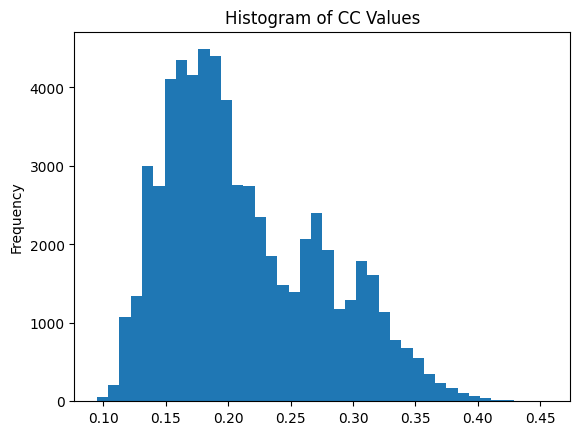

In [17]:
df["cc"].plot(kind="hist", title="Histogram of CC Values", bins=40)

Show the top fitted models and their scores.

In [ ]:
conn.execute("""
    SELECT
        f.* EXCLUDE (unfitted_model_file),
        s.* EXCLUDE (pdb_file),
        coalesce(f.unfitted_model_file, s.pdb_file) AS unfitted_model_file,
    FROM fitted_models AS f
    JOIN solutions AS s USING (powerfit_run_id, structure, rank)""").df()

,powerfit_run_id,structure,rank,fitted_model_file,powerfit_run_id_1,structure_1,rank_1,cc,fishz,relz,translation,rotation,density_filter_id,af_id,pdb_id,uniprot_acc,unfitted_model_file
0,1,A8MT69_4ne6_B2A,1,session1/powerfit/1/A8MT69_4ne6_B2A/fit_1.pdb,1,A8MT69_4ne6_B2A,1,0.456,0.492,11.071,"[227.18, 242.53, 211.83]","[0.0, -0.0, -1.0, 0.604, -0.797, 0.0, -0.797, ...",<NA>,None,4NE6,A8MT69,session1/single_chain/A8MT69_4ne6_B2A.pdb
1,1,A8MT69_4ne6_B2A,2,session1/powerfit/1/A8MT69_4ne6_B2A/fit_2.pdb,1,A8MT69_4ne6_B2A,2,0.438,0.470,10.571,"[138.15, 153.5, 138.15]","[-0.797, 0.604, 0.0, 0.604, 0.797, 0.0, 0.0, 0...",<NA>,None,4NE6,A8MT69,session1/single_chain/A8MT69_4ne6_B2A.pdb
2,1,A8MT69_4ne6_B2A,3,session1/powerfit/1/A8MT69_4ne6_B2A/fit_3.pdb,1,A8MT69_4ne6_B2A,3,0.428,0.457,10.297,"[227.18, 138.15, 227.18]","[-0.0, 0.0, 1.0, 0.0, 1.0, 0.0, -1.0, 0.0, -0.0]",<NA>,None,4NE6,A8MT69,session1/single_chain/A8MT69_4ne6_B2A.pdb
3,1,A8MT69_4ne6_B2A,4,session1/powerfit/1/A8MT69_4ne6_B2A/fit_4.pdb,1,A8MT69_4ne6_B2A,4,0.407,0.432,9.720,"[276.3, 248.67, 153.5]","[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0]",<NA>,None,4NE6,A8MT69,session1/single_chain/A8MT69_4ne6_B2A.pdb
4,1,A8MT69_4ne6_B2A,5,session1/powerfit/1/A8MT69_4ne6_B2A/fit_5.pdb,1,A8MT69_4ne6_B2A,5,0.399,0.422,9.498,"[184.2, 190.34, 205.69]","[0.816, 0.548, 0.184, -0.184, 0.548, -0.816, -...",<NA>,None,4NE6,A8MT69,session1/single_chain/A8MT69_4ne6_B2A.pdb
